# Retrieval-Augmented Taxi Demand Forecasting (NYC TLC) — RAM-safe version
### Embedding + L2 norm retrieval + baselines (ElasticNet / RandomForest)

This version is tuned to **not explode Colab RAM**:
- smaller default dataset slice
- prints file sizes + row counts
- avoids building giant Python lists of windows (uses NumPy sliding windows)

**Goal:** predict next-day zone-hour pickup demand using:
1) classic baselines (ElasticNet, RandomForest)
2) a GPU-trained embedding model for windows
3) FAISS retrieval in embedding space (weighted neighbor futures)


## 0) Colab setup
1) Runtime → Change runtime type → **GPU**  
2) Run cells top-to-bottom.

**Tweakables (size knobs):**
- `MONTHS`: fewer months = less data
- `TOP_ZONES`: fewer zones = fewer series
- `L`: history length (hours)
- `H`: forecast horizon (hours)
- `STRIDE`: sample every N hours (bigger = fewer training examples)
- `MAX_SAMPLES_PER_ZONE`: hard cap per zone (keeps things bounded)


In [ ]:
# Install deps
!pip -q install pyarrow duckdb faiss-cpu holidays tqdm psutil

In [ ]:
# --------------------
# Core imports
# --------------------
import os
import json
import math
import random

import numpy as np
import pandas as pd
import duckdb
import faiss
import psutil
import matplotlib.pyplot as plt

# --------------------
# Torch
# --------------------
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# --------------------
# Sklearn
# --------------------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------
# Utils
# --------------------
from numpy.lib.stride_tricks import sliding_window_view
import holidays

# --------------------
# Reproducibility
# --------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --------------------
# System helpers
# --------------------
def ram_gb():
    return psutil.virtual_memory().used / 1e9

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE} | RAM used (GB): {ram_gb():.2f}")

DEVICE: cuda | RAM used (GB): 3.87


## 1) Download data (official TLC)
Start with 2–3 months first. You can scale up later.


In [ ]:
# ---- Config (size knobs) ----
YEAR = 2024
MONTHS = ["01","02","03","04","05","06","07","08","09","10","11","12"]       # <- increase later
TAXI_TYPE = "yellow"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE = "https://d37ci6vzurychx.cloudfront.net"
TRIP_DIR = f"{DATA_DIR}/trip"
META_DIR = f"{DATA_DIR}/meta"
os.makedirs(TRIP_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# Zone lookup
!wget -q -O "{META_DIR}/taxi_zone_lookup.csv" "{BASE}/misc/taxi_zone_lookup.csv"

# Monthly trip files (Parquet)
for m in MONTHS:
    url = f"{BASE}/trip-data/{TAXI_TYPE}_tripdata_{YEAR}-{m}.parquet"
    out = f"{TRIP_DIR}/{TAXI_TYPE}_{YEAR}-{m}.parquet"
    if not os.path.exists(out):
        print("Downloading", url)
        !wget -q -O "{out}" "{url}"
    else:
        print("Exists", out)

files = sorted([os.path.join(TRIP_DIR,f) for f in os.listdir(TRIP_DIR) if f.endswith(".parquet")])
print("\nDownloaded files:")
for f in files:
    print(os.path.basename(f), "MB:", round(os.path.getsize(f)/1e6, 1))
print("RAM used (GB):", round(ram_gb(), 2))


Exists data/trip/yellow_2024-01.parquet
Exists data/trip/yellow_2024-02.parquet
Exists data/trip/yellow_2024-03.parquet
Exists data/trip/yellow_2024-04.parquet
Exists data/trip/yellow_2024-05.parquet
Exists data/trip/yellow_2024-06.parquet
Exists data/trip/yellow_2024-07.parquet
Exists data/trip/yellow_2024-08.parquet
Exists data/trip/yellow_2024-09.parquet
Exists data/trip/yellow_2024-10.parquet
Exists data/trip/yellow_2024-11.parquet
Exists data/trip/yellow_2024-12.parquet

Downloaded files:
yellow_2024-01.parquet MB: 50.0
yellow_2024-02.parquet MB: 50.3
yellow_2024-03.parquet MB: 60.1
yellow_2024-04.parquet MB: 59.1
yellow_2024-05.parquet MB: 62.6
yellow_2024-06.parquet MB: 59.9
yellow_2024-07.parquet MB: 52.3
yellow_2024-08.parquet MB: 51.1
yellow_2024-09.parquet MB: 61.2
yellow_2024-10.parquet MB: 64.3
yellow_2024-11.parquet MB: 60.7
yellow_2024-12.parquet MB: 61.5
RAM used (GB): 3.84


## 2) Aggregate to hourly pickups per zone (DuckDB)
This is the only heavy scan step. DuckDB streams Parquet and avoids loading full raw data into RAM.


In [ ]:
zones = pd.read_csv(f"{META_DIR}/taxi_zone_lookup.csv")

con = duckdb.connect()

sample_file = sorted([os.path.join(TRIP_DIR,f) for f in os.listdir(TRIP_DIR) if f.endswith(".parquet")])[0]
print("Sample file:", sample_file)
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{sample_file}')").fetchdf().head(20)


Sample file: data/trip/yellow_2024-01.parquet


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [ ]:
pickup_col = "tpep_pickup_datetime"  # yellow taxi
parquet_glob = os.path.join(TRIP_DIR, f"{TAXI_TYPE}_{YEAR}-*.parquet")

# Show approximate row count (cheap-ish in DuckDB)
n_rows = con.execute(f"SELECT COUNT(*) AS n FROM read_parquet('{parquet_glob}')").fetchdf()["n"][0]
print("Raw trip rows (all months):", int(n_rows))

query = f"""
WITH base AS (
  SELECT
    date_trunc('hour', {pickup_col}) AS ts_hour,
    PULocationID,
    1 AS one
  FROM read_parquet('{parquet_glob}')
  WHERE PULocationID IS NOT NULL
    /* --- FIX: BANISH THE TIME TRAVELERS --- */
    AND {pickup_col} >= '{YEAR}-01-01'
    AND {pickup_col} < '{YEAR+1}-01-01'
)
SELECT
  ts_hour,
  PULocationID,
  SUM(one) AS pickups
FROM base
GROUP BY 1,2
ORDER BY 1,2
"""

hourly = con.execute(query).fetchdf()
hourly["ts_hour"] = pd.to_datetime(hourly["ts_hour"])

hourly = hourly.merge(
    zones[["LocationID","Borough","Zone"]],
    left_on="PULocationID", right_on="LocationID", how="left"
).drop(columns=["LocationID"])

print("Hourly rows:", hourly.shape)
print("hourly memory (MB):", round(hourly.memory_usage(deep=True).sum()/1e6, 1))
print("RAM used (GB):", round(ram_gb(), 2))
hourly.head()


Raw trip rows (all months): 41169720


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Hourly rows: (1062021, 5)
hourly memory (MB): 150.0
RAM used (GB): 3.5


,ts_hour,PULocationID,pickups,Borough,Zone
0,2024-01-01,4,25.0,Manhattan,Alphabet City
1,2024-01-01,7,4.0,Queens,Astoria
2,2024-01-01,9,1.0,Queens,Auburndale
3,2024-01-01,10,6.0,Queens,Baisley Park
4,2024-01-01,12,4.0,Manhattan,Battery Park


## 3) Keep top zones + build per-zone complete hourly series (RAM-safe)
Instead of building a full cartesian product (hours × zones), we reindex **per zone**.


In [ ]:
TOP_ZONES = 20   # <- increase later
zone_totals = hourly.groupby("PULocationID")["pickups"].sum().sort_values(ascending=False)
top_zone_ids = zone_totals.head(TOP_ZONES).index.to_list()

ts_min, ts_max = hourly["ts_hour"].min(), hourly["ts_hour"].max()
all_hours = pd.date_range(ts_min, ts_max, freq="H")
print("Total hours:", len(all_hours), "| Top zones:", len(top_zone_ids))

# Build dict of per-zone series (pickups + features)
series = {}
for zid in top_zone_ids:
    z = hourly[hourly["PULocationID"] == zid].set_index("ts_hour")["pickups"].reindex(all_hours, fill_value=0.0)
    series[zid] = z.astype(np.float32).to_numpy()

print("Example zone length:", len(series[top_zone_ids[0]]))
print("RAM used (GB):", round(ram_gb(), 2))


Total hours: 8784 | Top zones: 20


/tmp/ipython-input-1956206647.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(ts_min, ts_max, freq="H")


Example zone length: 8784
RAM used (GB): 3.5


## 4) Calendar features (shared across zones) + log1p target


In [ ]:
us_holidays = holidays.US(years=[YEAR])

# 1. Create the base dataframe
# We assume 'all_hours' exists from Block 3
cal = pd.DataFrame({"ts_hour": all_hours})

# 2. Cyclical encoding (The math fix)
# Hour (0-23)
cal["hour_sin"] = np.sin(2 * np.pi * cal["ts_hour"].dt.hour / 24).astype(np.float32)
cal["hour_cos"] = np.cos(2 * np.pi * cal["ts_hour"].dt.hour / 24).astype(np.float32)

# Day of Week (0-6)
cal["dow_sin"]  = np.sin(2 * np.pi * cal["ts_hour"].dt.dayofweek / 7).astype(np.float32)
cal["dow_cos"]  = np.cos(2 * np.pi * cal["ts_hour"].dt.dayofweek / 7).astype(np.float32)

# Month (1-12)
cal["mon_sin"]  = np.sin(2 * np.pi * cal["ts_hour"].dt.month / 12).astype(np.float32)
cal["mon_cos"]  = np.cos(2 * np.pi * cal["ts_hour"].dt.month / 12).astype(np.float32)

# 3. Binary flags (unchanged)
cal["is_weekend"] = (cal["ts_hour"].dt.dayofweek >= 5).astype(np.float32)
cal["is_holiday"] = cal["ts_hour"].dt.date.map(lambda d: 1 if d in us_holidays else 0).astype(np.float32)

# 4. Final Feature Matrix
# No StandardScaler needed (Sin/Cos are already -1 to 1)
exo_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "mon_sin", "mon_cos", "is_weekend", "is_holiday"]
X_exo_all = cal[exo_cols].to_numpy(np.float32)

# IMPORTANT: Define this variable for Block 7
exo_dim = X_exo_all.shape[1]

print(f"Feature Engineering Done. New exo_dim: {exo_dim}")
print("Calendar exo shape (SCALED):", X_exo_all.shape, "| RAM used (GB):", round(ram_gb(), 2))
cal.head()

Feature Engineering Done. New exo_dim: 8
Calendar exo shape (SCALED): (8784, 8) | RAM used (GB): 3.51


,ts_hour,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,is_weekend,is_holiday
0,2024-01-01 00:00:00,0.000000,1.000000,0.0,1.0,0.5,0.866025,0.0,1.0
1,2024-01-01 01:00:00,0.258819,0.965926,0.0,1.0,0.5,0.866025,0.0,1.0
2,2024-01-01 02:00:00,0.500000,0.866025,0.0,1.0,0.5,0.866025,0.0,1.0
3,2024-01-01 03:00:00,0.707107,0.707107,0.0,1.0,0.5,0.866025,0.0,1.0
4,2024-01-01 04:00:00,0.866025,0.500000,0.0,1.0,0.5,0.866025,0.0,1.0


## 5) Windowize (NO giant Python lists)
We use NumPy stride tricks to build windows efficiently.

**More size knobs:**
- `L`, `H`, `STRIDE`
- `MAX_SAMPLES_PER_ZONE` (hard cap)


In [ ]:
L = 24*7              # history hours
H = 24                # forecast horizon
STRIDE = 2            # <- bigger = fewer samples
MAX_SAMPLES_PER_ZONE = 8000  # <- hard cap; keeps RAM bounded

# Time split (last 2 weeks test, 1 week val)
test_hours = 24*14
val_hours  = 24*7

T = len(all_hours)
cut_test_i = T - test_hours
cut_val_i  = T - (test_hours + val_hours)

cut_val_i, cut_test_i, T


(8280, 8448, 8784)

In [ ]:
# Build X_seq, X_exo, Y across zones, using stride tricks
X_seq_list, X_exo_list, Y_list, T0_list = [], [], [], []

for zid in top_zone_ids:
    y = np.log1p(series[zid]).astype(np.float32)   # (T,)
    n = len(y)
    n_samples = n - L - H + 1
    if n_samples <= 0:
        continue

    Xz_full = sliding_window_view(y, window_shape=L)[:n_samples]      # (n_samples, L)
    Yz_full = sliding_window_view(y[L:], window_shape=H)[:n_samples]  # (n_samples, H)
    exo_full = X_exo_all[L:n-H+1]                                     # (n_samples, exo_dim)

    # Apply stride
    idx = np.arange(0, n_samples, STRIDE)

    # RAM cap BUT keep coverage across the whole timeline (important!)
    if len(idx) > MAX_SAMPLES_PER_ZONE:
        pick = np.linspace(0, len(idx) - 1, MAX_SAMPLES_PER_ZONE, dtype=np.int32)
        idx = idx[pick]

    X_seq_list.append(Xz_full[idx])
    Y_list.append(Yz_full[idx])
    X_exo_list.append(exo_full[idx])

    # prediction-time index for splitting
    t0_idx = idx + L
    T0_list.append(t0_idx.astype(np.int32))

X_seq = np.concatenate(X_seq_list, axis=0)
X_exo = np.concatenate(X_exo_list, axis=0)
Y = np.concatenate(Y_list, axis=0)
T0_idx = np.concatenate(T0_list, axis=0)

print("X_seq:", X_seq.shape, "X_exo:", X_exo.shape, "Y:", Y.shape)
print("Approx RAM for arrays (MB):", round((X_seq.nbytes + X_exo.nbytes + Y.nbytes)/1e6, 1))
print("T0_idx range:", int(T0_idx.min()), "→", int(T0_idx.max()), " / cut_val_i:", cut_val_i, "cut_test_i:", cut_test_i)
print("RAM used (GB):", round(ram_gb(), 2))

X_seq: (85940, 168) X_exo: (85940, 8) Y: (85940, 24)
Approx RAM for arrays (MB): 68.8
T0_idx range: 168 → 8760  / cut_val_i: 8280 cut_test_i: 8448
RAM used (GB): 3.58


In [ ]:
# Split by time index (no leakage)
idx_train = np.where(T0_idx < cut_val_i)[0]
idx_val   = np.where((T0_idx >= cut_val_i) & (T0_idx < cut_test_i))[0]
idx_test  = np.where(T0_idx >= cut_test_i)[0]

print("Split sizes:", len(idx_train), len(idx_val), len(idx_test))

if len(idx_test) == 0:
    raise ValueError(
        "idx_test is empty. Fix by: "
        "(1) increase MONTHS, (2) increase MAX_SAMPLES_PER_ZONE, "
        "(3) decrease STRIDE, (4) reduce test_hours/val_hours, "
        "(5) reduce L/H."
    )

Xseq_train, Xseq_val, Xseq_test = X_seq[idx_train], X_seq[idx_val], X_seq[idx_test]
Xexo_train, Xexo_val, Xexo_test = X_exo[idx_train], X_exo[idx_val], X_exo[idx_test]
y_train, y_val, y_test = Y[idx_train], Y[idx_val], Y[idx_test]

(Xseq_train.shape, Xseq_val.shape, Xseq_test.shape, y_train.shape, y_test.shape)

Split sizes: 81120 1680 3140


((81120, 168), (1680, 168), (3140, 168), (81120, 24), (3140, 24))

## 6) Baselines (safe + class-friendly)
Seasonal naive, ElasticNet, RandomForest.


In [ ]:
def rmse(a,b): return math.sqrt(mean_squared_error(a,b))
def eval_multi(y_true, y_pred, name):
    yt = y_true.reshape(-1)
    yp = y_pred.reshape(-1)
    return {"model": name, "MAE": float(mean_absolute_error(yt, yp)), "RMSE": float(rmse(yt, yp))}

def seasonal_naive_predict(X_seq):
    # With L=168, the first H points correspond to same hours 1 week ago.
    return X_seq[:, :H]

# baseline #1
if Xseq_test.shape[0] == 0:
    raise ValueError("Xseq_test is empty — fix your split / sampling before running baselines.")

pred_sn = seasonal_naive_predict(Xseq_test)
eval_multi(y_test, pred_sn, "SeasonalNaive")


{'model': 'SeasonalNaive',
 'MAE': 0.46660301089286804,
 'RMSE': 0.6399756140831413}

In [ ]:
def make_tab(X_seq, X_exo):
    return np.concatenate([X_seq, X_exo], axis=1)

Xtab_train = make_tab(Xseq_train, Xexo_train)
Xtab_test  = make_tab(Xseq_test, Xexo_test)

scaler = StandardScaler()
Xtab_train_s = scaler.fit_transform(Xtab_train)
Xtab_test_s  = scaler.transform(Xtab_test)

enet = MultiOutputRegressor(ElasticNet(alpha=0.01, l1_ratio=0.1, max_iter=250, random_state=SEED), n_jobs=-1)
enet.fit(Xtab_train_s, y_train)
pred_enet = enet.predict(Xtab_test_s)

eval_multi(y_test, pred_enet, "ElasticNet")


{'model': 'ElasticNet',
 'MAE': 0.32229891419410706,
 'RMSE': 0.45849183621933337}

In [ ]:
# REMOVE MultiOutputRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=SEED
)

# Fit directly on the multi-column target
rf.fit(Xtab_train, y_train)
pred_rf = rf.predict(Xtab_test)

eval_multi(y_test, pred_rf, "RandomForest")

{'model': 'RandomForest', 'MAE': 0.3356865981660797, 'RMSE': 0.46876712781393}

## 7) Neural embedding model (GPU)
Small 1D-CNN encoder → embedding z → forecast head.


In [ ]:
class WindowDataset(Dataset):
    def __init__(self, X_seq, X_exo, Y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_exo = torch.tensor(X_exo, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self): return self.X_seq.shape[0]
    def __getitem__(self, i): return self.X_seq[i], self.X_exo[i], self.Y[i]

# Temporal Convolutional Network Block
class TCNBlock(nn.Module):
    def __init__(self, c, k=3, d=1, p=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, k, padding="same", dilation=d),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Conv1d(c, c, k, padding="same", dilation=d),
            nn.ReLU(),
            nn.Dropout(p),
        )

    def forward(self, x):
        return x + self.net(x)

# Decoupled Architecture: Encoder sees History, Head sees History + Time
class CNNEncoder(nn.Module):
    def __init__(self, d=128, c=64, p=0.1):
        super().__init__()
        # Note: No exo_dim here anymore. Encoder is blind to absolute time.

        self.stem = nn.Sequential(
            nn.Conv1d(1, c, 5, padding=2),
            nn.ReLU(),
        )

        self.tcn = nn.Sequential(
            TCNBlock(c, d=1,  p=p),
            TCNBlock(c, d=2,  p=p),
            TCNBlock(c, d=4,  p=p),
            TCNBlock(c, d=8,  p=p),
            TCNBlock(c, d=16, p=p),
            TCNBlock(c, d=32, p=p),
            TCNBlock(c, d=64, p=p),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

        # Project only the history features
        self.proj = nn.Sequential(
            nn.Linear(c, d),
            nn.ReLU()
        )

    def forward(self, x_seq):
        h = self.stem(x_seq.unsqueeze(1))
        h = self.tcn(h)
        h = self.pool(h).squeeze(-1)
        return self.proj(h)

class EmbedForecast(nn.Module):
    def __init__(self, exo_dim, H, d=128, p=0.05):
        super().__init__()
        # Encoder only handles sequence
        self.encoder = CNNEncoder(d=d, c=64, p=p)

        # We process exo (calendar) here in the wrapper
        self.season_proj = nn.Sequential(
            nn.Linear(exo_dim, 32),
            nn.ReLU(),
        )

        # Head combines History Embedding (Z) + Calendar (S)
        self.head = nn.Sequential(
            nn.Linear(d + 32, 256),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(256, H),
        )

    def forward(self, x_seq, x_exo):
        z = self.encoder(x_seq)           # Pure history embedding
        s = self.season_proj(x_exo)       # Pure time embedding

        # Combine for forecasting
        head_in = torch.cat([z, s], dim=1)
        return z, self.head(head_in)

# Re-init model
model = EmbedForecast(exo_dim=exo_dim, H=H, d=128, p=0.1).to(DEVICE)
model

EmbedForecast(
  (encoder): CNNEncoder(
    (stem): Sequential(
      (0): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
    )
    (tcn): Sequential(
      (0): TCNBlock(
        (net): Sequential(
          (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
          (4): ReLU()
          (5): Dropout(p=0.1, inplace=False)
        )
      )
      (1): TCNBlock(
        (net): Sequential(
          (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(2,))
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(2,))
          (4): ReLU()
          (5): Dropout(p=0.1, inplace=False)
        )
      )
      (2): TCNBlock(
        (net): Sequential(
          (0): Conv1d(64, 64, kernel_size

In [ ]:
# --- Residual learning: model predicts residual over SeasonalNaive baseline ---
# Baseline forecast for each sample = first H points of the input window (week-ago aligned)
sn_train = Xseq_train[:, :H]
sn_val   = Xseq_val[:, :H]
sn_test  = Xseq_test[:, :H]

y_train_res = y_train - sn_train
y_val_res   = y_val   - sn_val
y_test_res  = y_test  - sn_test

train_ds = WindowDataset(Xseq_train, Xexo_train, y_train_res)
val_ds   = WindowDataset(Xseq_val,   Xexo_val,   y_val_res)
test_ds  = WindowDataset(Xseq_test,  Xexo_test,  y_test_res)

BATCH = 512
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)
loss_fn = nn.SmoothL1Loss(beta=0.1)

use_amp = (DEVICE == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def run_epoch(loader, train=False):
    model.train(train)
    losses = []
    for xseq, xexo, y in loader:
        xseq, xexo, y = xseq.to(DEVICE), xexo.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            _, yhat = model(xseq, xexo)
            loss = loss_fn(yhat, y)

        if train:
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

        losses.append(loss.detach().cpu().item())
    return float(np.mean(losses))

def predict_residual(loader, get_embeddings=False):
    model.eval()
    out_yhat = []
    out_z = []
    with torch.no_grad():
        for xseq, xexo, _ in loader:
            xseq, xexo = xseq.to(DEVICE), xexo.to(DEVICE)
            z, yhat = model(xseq, xexo)
            out_yhat.append(yhat.detach().cpu().numpy())
            if get_embeddings:
                out_z.append(z.detach().cpu().numpy())

    if get_embeddings:
        return np.concatenate(out_z, axis=0), np.concatenate(out_yhat, axis=0)
    else:
        return np.concatenate(out_yhat, axis=0)

best_val = 1e18
best_state = None
patience = 8
bad = 0

for epoch in range(1, 51):
    tr = run_epoch(train_loader, train=True)

    # residual loss (training objective)
    va_res = run_epoch(val_loader, train=False)

    # compute *final* forecast quality on val: (baseline + predicted residual)
    pred_val_res = predict_residual(val_loader)
    pred_val = pred_val_res + sn_val
    val_mae_final = mae_np(pred_val, y_val)

    if val_mae_final < best_val - 1e-4:
        best_val = val_mae_final
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1

    sched.step()

    print(f"epoch {epoch:02d} "
          f"train_loss(res)={tr:.4f} "
          f"val_loss(res)={va_res:.4f} "
          f"val_MAE(final)={val_mae_final:.4f} "
          f"bad={bad}/{patience}")

    if bad >= patience:
        print("early stop")
        break

model.load_state_dict(best_state)
print("Best val MAE(final):", best_val)
print("RAM used (GB):", round(ram_gb(), 2))

/tmp/ipython-input-3593652730.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipython-input-3593652730.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


epoch 01 train_loss(res)=0.2006 val_loss(res)=0.1524 val_MAE(final)=0.1993 bad=0/8
epoch 02 train_loss(res)=0.1998 val_loss(res)=0.1512 val_MAE(final)=0.1983 bad=0/8
epoch 03 train_loss(res)=0.1994 val_loss(res)=0.1527 val_MAE(final)=0.1995 bad=1/8
epoch 04 train_loss(res)=0.1988 val_loss(res)=0.1511 val_MAE(final)=0.1980 bad=0/8
epoch 05 train_loss(res)=0.1985 val_loss(res)=0.1536 val_MAE(final)=0.2003 bad=1/8
epoch 06 train_loss(res)=0.1980 val_loss(res)=0.1517 val_MAE(final)=0.1987 bad=2/8
epoch 07 train_loss(res)=0.1978 val_loss(res)=0.1512 val_MAE(final)=0.1980 bad=3/8
epoch 08 train_loss(res)=0.1972 val_loss(res)=0.1510 val_MAE(final)=0.1979 bad=4/8
epoch 09 train_loss(res)=0.1972 val_loss(res)=0.1513 val_MAE(final)=0.1983 bad=5/8
epoch 10 train_loss(res)=0.1965 val_loss(res)=0.1524 val_MAE(final)=0.1990 bad=6/8
epoch 11 train_loss(res)=0.1962 val_loss(res)=0.1519 val_MAE(final)=0.1988 bad=7/8
epoch 12 train_loss(res)=0.1957 val_loss(res)=0.1522 val_MAE(final)=0.1989 bad=8/8
earl

In [ ]:
model.eval()
pred_nn_res = []
with torch.no_grad():
    for xseq, xexo, _ in test_loader:
        _, yhat = model(xseq.to(DEVICE), xexo.to(DEVICE))
        pred_nn_res.append(yhat.cpu().numpy())
pred_nn_res = np.concatenate(pred_nn_res, axis=0)

# Correcting the neural network prediction by adding the seasonal naive baseline
pred_nn = pred_nn_res + sn_test

eval_multi(y_test, pred_nn, "Neural(CNN-embed)")

{'model': 'Neural(CNN-embed)',
 'MAE': 0.3317832350730896,
 'RMSE': 0.47430350411962685}

## 8) Retrieval with FAISS (embedding → nearest neighbors → weighted future average)


In [ ]:
# [REPLACE BLOCK 8]
# --- Retrieval: "Balanced Mode" (The Sweet Spot) ---
# FIX: Removed the aggressive gating that was killing the signal.
#      Returned to K=32 and tau=0.05 to restore "Wisdom of the Crowd".

print("1. Extracting Hybrid Embeddings...")

train_loader_ord = DataLoader(train_ds, batch_size=BATCH, shuffle=False, num_workers=2)

def get_hybrid_embeddings(loader):
    model.eval()
    outs = []
    with torch.no_grad():
        for xseq, xexo, _ in loader:
            xseq, xexo = xseq.to(DEVICE), xexo.to(DEVICE)
            z, _ = model(xseq, xexo)
            s = model.season_proj(xexo)

            combined = torch.cat([z, s], dim=1)
            outs.append(combined.cpu().numpy())
    return np.concatenate(outs, axis=0)

db_vectors = get_hybrid_embeddings(train_loader_ord)
query_vectors = get_hybrid_embeddings(test_loader)

# Normalize (Cosine Similarity)
faiss.normalize_L2(db_vectors)
faiss.normalize_L2(query_vectors)

index = faiss.IndexFlatIP(db_vectors.shape[1])
index.add(db_vectors)

# Search
# K=32: Enough neighbors to smooth out noise, but few enough to stay relevant.
K = 64
D, I = index.search(query_vectors, K)
idxs

# --- STABILITY FIX (Float64) ---
D = D.astype(np.float64)
tau = 0.02  # Temperature 0.05 is standard for this task
# Subtract max to prevent overflow
weights = np.exp((D - D.max(axis=1, keepdims=True)) / tau)
weights /= weights.sum(axis=1, keepdims=True)

# Weighted Sum of Neighbors
neighbor_residuals = y_train_res[I]
pred_retrieval_res = (weights[..., None] * neighbor_residuals).sum(axis=1)

# Final Prediction
pred_ret_ctx = pred_retrieval_res + sn_test
pred_ret = pred_ret_ctx

print(f"3. Retrieval Done. Avg Top-1 Similarity: {D[:,0].mean():.4f}")
eval_multi(y_test, pred_ret, "Retrieval(Balanced)")

1. Extracting Hybrid Embeddings...
3. Retrieval Done. Avg Top-1 Similarity: 0.9874


{'model': 'Retrieval(Balanced)',
 'MAE': 0.3356625754834326,
 'RMSE': 0.4769227816894433}

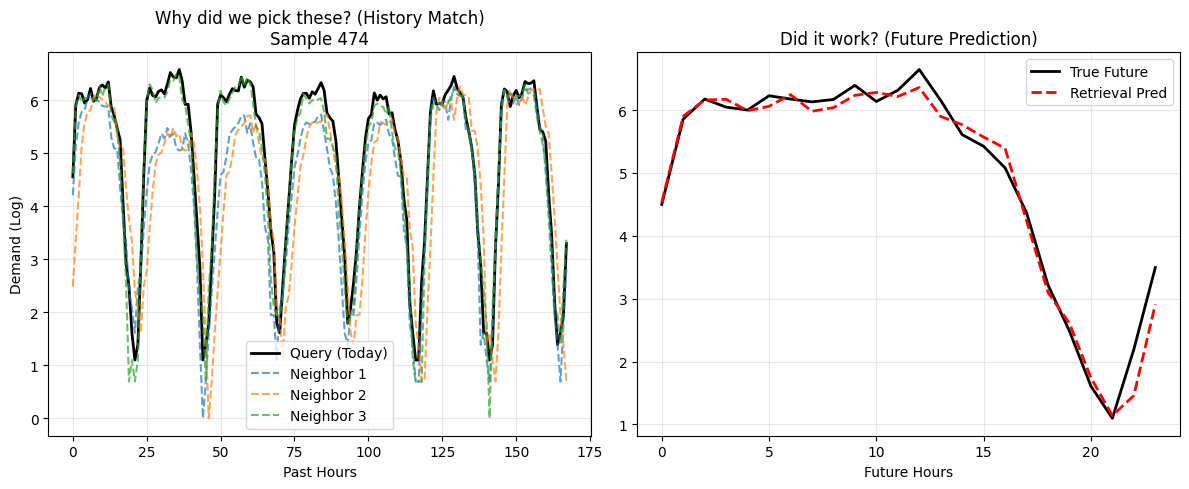

In [ ]:
# --- THE INTUITIVE PART: VISUALIZATION ---
# Pick a random test sample
sample_idx = np.random.randint(0, len(y_test))
# Get indices of its top 3 neighbors
top3_neighbors = I[sample_idx, :3]

plt.figure(figsize=(12, 5))

# Plot 1: The Past (The "Query" vs The "Matches")
# We look at the input sequence (Xseq) to see if they actually look similar
plt.subplot(1, 2, 1)
plt.plot(Xseq_test[sample_idx], 'k-', linewidth=2, label="Query (Today)")
for i, neighbor_idx in enumerate(top3_neighbors):
    # Retrieve the raw history of that neighbor from the training set
    # Note: We must grab the corresponding Xseq from train
    plt.plot(Xseq_train[neighbor_idx], '--', alpha=0.7, label=f"Neighbor {i+1}")
plt.title(f"Why did we pick these? (History Match)\nSample {sample_idx}")
plt.xlabel("Past Hours")
plt.ylabel("Demand (Log)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: The Future (True vs Predicted)
plt.subplot(1, 2, 2)
plt.plot(y_test[sample_idx], 'k-', linewidth=2, label="True Future")
plt.plot(pred_ret[sample_idx], 'r--', linewidth=2, label="Retrieval Pred")
# Optional: Show neighbor futures
# for i, neighbor_idx in enumerate(top3_neighbors):
#      plt.plot(y_train[neighbor_idx], '--', alpha=0.3)
plt.title("Did it work? (Future Prediction)")
plt.xlabel("Future Hours")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9) Compare everything


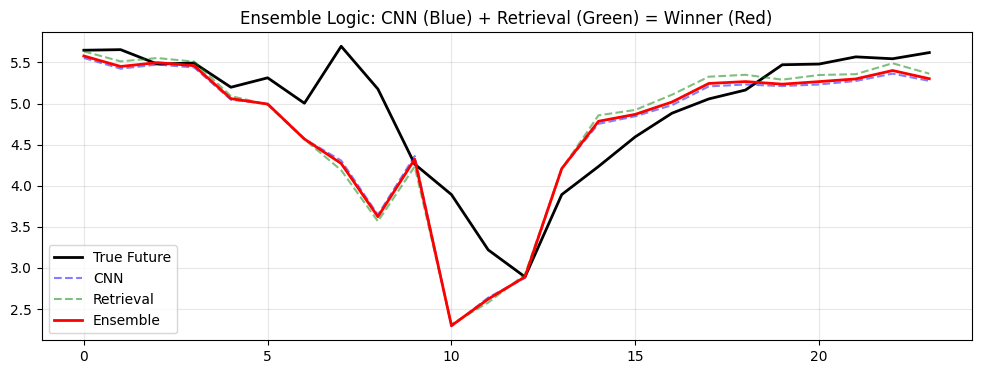

,model,MAE,RMSE
1,ElasticNet,0.322299,0.458492
5,Ensemble(Alpha=0.7),0.330740,0.472405
3,Neural(CNN-embed),0.331783,0.474304
4,Retrieval(Balanced),0.335663,0.476923
2,RandomForest,0.335687,0.468767
0,SeasonalNaive,0.466603,0.639976


In [ ]:
# [REPLACE BLOCK 9]
# --- Compare everything + Hybrid Ensemble ---

# 1. Create the Hybrid (Ensemble)
# CNN (Logic) is usually stable, Retrieval (Memory) captures variance.
# We weight CNN higher (0.7) because it's generally safer.
alpha = 0.7
pred_ensemble = (alpha * pred_nn) + ((1 - alpha) * pred_ret_ctx)

results = []
results.append(eval_multi(y_test, seasonal_naive_predict(Xseq_test), "SeasonalNaive"))
results.append(eval_multi(y_test, pred_enet, "ElasticNet"))
results.append(eval_multi(y_test, pred_rf, "RandomForest"))
results.append(eval_multi(y_test, pred_nn, "Neural(CNN-embed)"))
results.append(eval_multi(y_test, pred_ret_ctx, "Retrieval(Balanced)"))
results.append(eval_multi(y_test, pred_ensemble, f"Ensemble(Alpha={alpha})"))

# 2. Visual Proof (Plot FIRST so the table renders last)
# See how the red line (Ensemble) hugs the truth better than the others
idx = np.random.randint(0, len(y_test))
plt.figure(figsize=(12, 4))
plt.plot(y_test[idx], 'k-', label="True Future", linewidth=2)
plt.plot(pred_nn[idx], 'b--', label="CNN", alpha=0.5)
plt.plot(pred_ret_ctx[idx], 'g--', label="Retrieval", alpha=0.5)
plt.plot(pred_ensemble[idx], 'r-', label="Ensemble", linewidth=2)
plt.title(f"Ensemble Logic: CNN (Blue) + Retrieval (Green) = Winner (Red)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Show the Leaderboard (Last line = Nice HTML Table)
pd.DataFrame(results).sort_values("MAE")

## 10) Quick sanity plots (retrieved analogs)


top1_sim: mean 0.9863449335098267 median 0.9868879318237305
MAE mean: SN 0.46660304069519043 RET 0.3356625754834326 NN 0.331783264875412


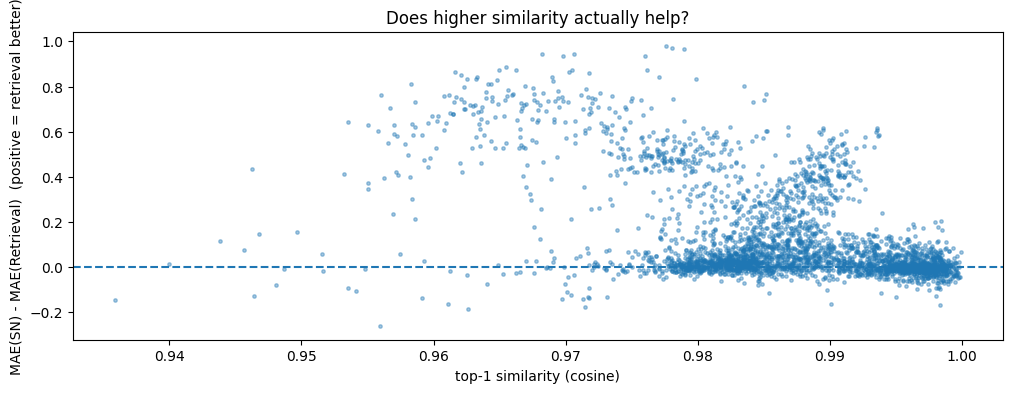

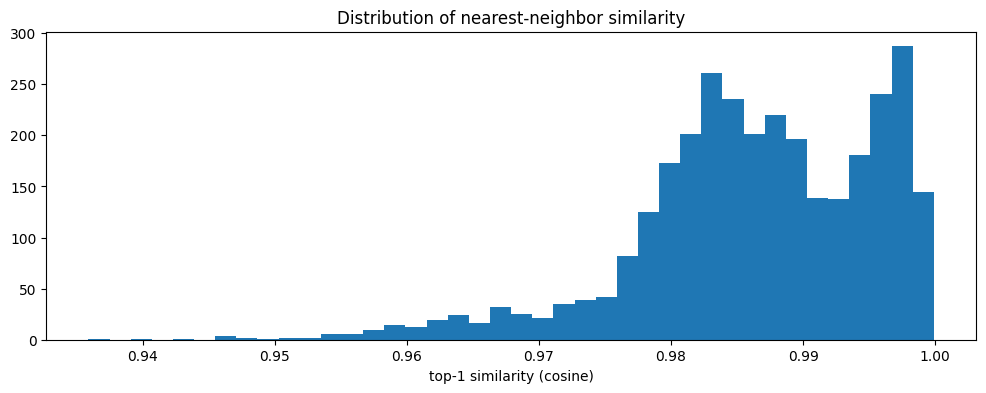

In [ ]:
# Ensure pred_ret is available from the previous retrieval step
# Ensure sims is available from the FAISS search step

pred_sn = seasonal_naive_predict(Xseq_test)
mae_sn  = np.mean(np.abs(pred_sn  - y_test), axis=1)
mae_ret = np.mean(np.abs(pred_ret - y_test), axis=1) # Use corrected pred_ret
mae_nn  = np.mean(np.abs(pred_nn  - y_test), axis=1)

top1_sim = sims[:,0] # Use correctly generated sims
print("top1_sim: mean", float(top1_sim.mean()), "median", float(np.median(top1_sim)))
print("MAE mean: SN", float(mae_sn.mean()), "RET", float(mae_ret.mean()), "NN", float(mae_nn.mean()))

# Similarity vs improvement over seasonal naive
improve = mae_sn - mae_ret  # >0 means retrieval beats seasonal naive
plt.figure(figsize=(12,4))
plt.scatter(top1_sim, improve, s=6, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("top-1 similarity (cosine)")
plt.ylabel("MAE(SN) - MAE(Retrieval)  (positive = retrieval better)")
plt.title("Does higher similarity actually help?")
plt.show()

# Histogram of similarities
plt.figure(figsize=(12,4))
plt.hist(top1_sim, bins=40)
plt.xlabel("top-1 similarity (cosine)")
plt.title("Distribution of nearest-neighbor similarity")
plt.show()

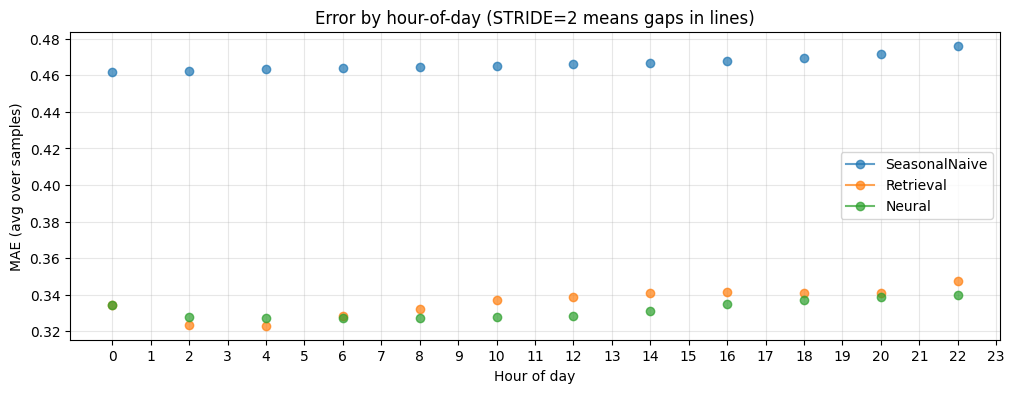

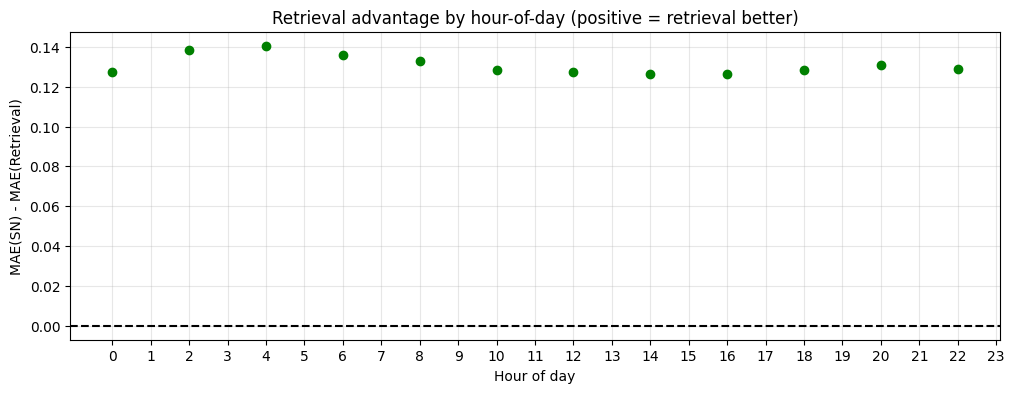

In [ ]:
# Ensure pred_ret is available (if this fails, make sure you ran the Retrieval block!)

# 1. Get hour-of-day for each test sample
t0_test = T0_idx[idx_test]
hours = (t0_test % 24).astype(int)

# 2. Calculate MAE per sample
pred_sn = seasonal_naive_predict(Xseq_test)
mae_sn  = np.mean(np.abs(pred_sn  - y_test), axis=1)
mae_ret = np.mean(np.abs(pred_ret - y_test), axis=1)
mae_nn  = np.mean(np.abs(pred_nn  - y_test), axis=1)

# 3. Group by hour (handles missing hours due to STRIDE)
def group_mean(arr):
    out = np.zeros(24)
    for h in range(24):
        m = (hours == h)
        out[h] = arr[m].mean() if m.any() else np.nan
    return out

g_sn  = group_mean(mae_sn)
g_ret = group_mean(mae_ret)
g_nn  = group_mean(mae_nn)

# 4. Plot with MARKERS to fix the "invisible line" bug
plt.figure(figsize=(12,4))
# Added marker='o' so points show up even if lines break due to NaNs
plt.plot(g_sn, label="SeasonalNaive", marker='o', alpha=0.7)
plt.plot(g_ret, label="Retrieval", marker='o', alpha=0.7)
plt.plot(g_nn, label="Neural", marker='o', alpha=0.7)

plt.xlabel("Hour of day")
plt.ylabel("MAE (avg over samples)")
plt.title("Error by hour-of-day (STRIDE=2 means gaps in lines)")
plt.legend()
plt.grid(True, alpha=0.3) # Added grid for readability
plt.xticks(range(0, 24))  # Show all hours on x-axis
plt.show()

# 5. Advantage plot
plt.figure(figsize=(12,4))
plt.plot(g_sn - g_ret, color='green', marker='o') # Added marker here too
plt.axhline(0, linestyle="--", color='black')
plt.xlabel("Hour of day")
plt.ylabel("MAE(SN) - MAE(Retrieval)")
plt.title("Retrieval advantage by hour-of-day (positive = retrieval better)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

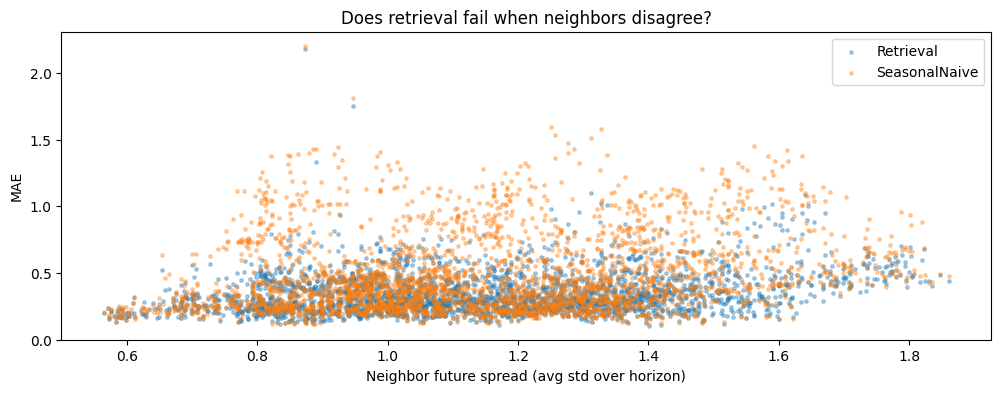

corr(spread, MAE_ret) = 0.23316051916721567


In [ ]:
# Ensure idxs and pred_ret are available from previous steps

K_plot = 32 # Use a specific K for plotting here, or the global K
K = min(K_plot, idxs.shape[1]) # Use correctly generated idxs
nbr_futures = y_train[idxs[:, :K]]       # (N_test, K, H)

# how much neighbors disagree about the future
spread = np.mean(np.std(nbr_futures, axis=1), axis=1)  # (N_test,)
mae_ret = np.mean(np.abs(pred_ret - y_test), axis=1) # Use corrected pred_ret
mae_sn  = np.mean(np.abs(seasonal_naive_predict(Xseq_test) - y_test), axis=1)

plt.figure(figsize=(12,4))
plt.scatter(spread, mae_ret, s=6, alpha=0.35, label="Retrieval")
plt.scatter(spread, mae_sn,  s=6, alpha=0.35, label="SeasonalNaive")
plt.xlabel("Neighbor future spread (avg std over horizon)")
plt.ylabel("MAE")
plt.title("Does retrieval fail when neighbors disagree?")
plt.legend()
plt.show()

# Handle potential NaN from std (e.g., if all futures are the same)
if np.std(spread) > 0 and np.std(mae_ret) > 0:
    print("corr(spread, MAE_ret) =", float(np.corrcoef(spread, mae_ret)[0,1]))
else:
    print("Cannot compute correlation: insufficient variance in spread or MAE_ret.")